<a href="https://colab.research.google.com/github/rubytechme/Customer-Analytics-RFM-Forecasting-Python-/blob/main/Customer_Analytics_RFM_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
================================================================================
E-COMMERCE CUSTOMER BEHAVIOR & SALES FORECASTING - PYTHON PROJECT
================================================================================


PROJECT STRUCTURE:
1. Data Loading & Initial Exploration
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Customer Segmentation (RFM Analysis)
6. Sales Forecasting (Time Series)
7. Insights & Recommendations
8. Export to Database (SQLite)

LIBRARIES REQUIRED:
- pandas, numpy (data manipulation)
- matplotlib, seaborn, plotly (visualization)
- scikit-learn (ML & preprocessing)
- statsmodels (time series)
- sqlite3 (database)
================================================================================
"""

# SECTION 1: ENVIRONMENT SETUP & DATA GENERATION

In [13]:
# Install required libraries (run this in Colab)
!pip install plotly statsmodels -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime, timedelta
import warnings
import sqlite3
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2


# SECTION 2: DATA GENERATION (Simulating E-commerce Dataset)


In [14]:
def generate_ecommerce_data(n_customers=5000, n_transactions=50000):
    """
    Generate realistic e-commerce transaction data
    """
    np.random.seed(42)

    # Generate customer data
    customer_ids = [f"CUST{str(i).zfill(5)}" for i in range(1, n_customers + 1)]
    countries = ['USA', 'UK', 'Germany', 'France', 'Canada', 'Australia', 'Spain', 'Italy']
    customer_segments = ['Premium', 'Regular', 'Occasional']

    customers = pd.DataFrame({
        'customer_id': customer_ids,
        'country': np.random.choice(countries, n_customers, p=[0.30, 0.20, 0.15, 0.10, 0.10, 0.05, 0.05, 0.05]),
        'registration_date': [datetime(2022, 1, 1) + timedelta(days=int(x))
                             for x in np.random.exponential(180, n_customers)],
        'customer_segment': np.random.choice(customer_segments, n_customers, p=[0.15, 0.55, 0.30])
    })

    # Generate transaction data
    transaction_ids = [f"TXN{str(i).zfill(6)}" for i in range(1, n_transactions + 1)]
    product_categories = ['Electronics', 'Clothing', 'Home & Garden', 'Sports', 'Books', 'Toys', 'Beauty']
    payment_methods = ['Credit Card', 'PayPal', 'Debit Card', 'Bank Transfer']

    # Transaction dates weighted towards recent months
    base_date = datetime(2023, 1, 1)
    transaction_dates = [base_date + timedelta(days=int(x))
                        for x in np.random.exponential(90, n_transactions)]

    transactions = pd.DataFrame({
        'transaction_id': transaction_ids,
        'customer_id': np.random.choice(customer_ids, n_transactions),
        'transaction_date': transaction_dates,
        'product_category': np.random.choice(product_categories, n_transactions),
        'quantity': np.random.randint(1, 10, n_transactions),
        'unit_price': np.random.uniform(10, 500, n_transactions),
        'discount_percent': np.random.choice([0, 5, 10, 15, 20, 25], n_transactions, p=[0.4, 0.2, 0.15, 0.15, 0.05, 0.05]),
        'payment_method': np.random.choice(payment_methods, n_transactions),
        'shipping_cost': np.random.uniform(0, 25, n_transactions),
        'is_returned': np.random.choice([0, 1], n_transactions, p=[0.92, 0.08])
    })

    # Calculate total amount
    transactions['total_amount'] = (
        transactions['quantity'] * transactions['unit_price'] *
        (1 - transactions['discount_percent'] / 100) +
        transactions['shipping_cost']
    )

    # Add some missing values intentionally for data cleaning practice
    transactions.loc[np.random.choice(transactions.index, 250), 'discount_percent'] = np.nan
    transactions.loc[np.random.choice(transactions.index, 150), 'shipping_cost'] = np.nan
    customers.loc[np.random.choice(customers.index, 100), 'customer_segment'] = np.nan

    return customers, transactions

# Generate data
print("🔄 Generating e-commerce dataset...")
customers_df, transactions_df = generate_ecommerce_data()

print(f"\n✅ Data generated successfully!")
print(f"📊 Customers: {len(customers_df):,} records")
print(f"📊 Transactions: {len(transactions_df):,} records")
print(f"📅 Date Range: {transactions_df['transaction_date'].min().date()} to {transactions_df['transaction_date'].max().date()}")


🔄 Generating e-commerce dataset...

✅ Data generated successfully!
📊 Customers: 5,000 records
📊 Transactions: 50,000 records
📅 Date Range: 2023-01-01 to 2025-08-01


This data was generated because i want to achieve the following goal with this projrct


*   Enable High Customization – To ensure adjustable parameters (size, behavioral patterns, and complexity) so the data can adapt to different testing scenarios and model requirements.

*   Zero Privacy Risk – To fully synthetic data with no real customer information, ensuring complete data protection and compliance.


*   Realistic Behavioral Patterns – To use statistical distributions to closely simulate real-world user behavior and trends.





# SECTION 3: INITIAL DATA EXPLORATION


In [15]:
print("\n" + "="*80)
print("DATA EXPLORATION - CUSTOMERS")
print("="*80)
print(customers_df.head(10))
print(f"\nShape: {customers_df.shape}")
print("\nData Types:")
print(customers_df.dtypes)
print("\nMissing Values:")
print(customers_df.isnull().sum())
print("\nBasic Statistics:")
print(customers_df.describe(include='all'))

print("\n" + "="*80)
print("DATA EXPLORATION - TRANSACTIONS")
print("="*80)
print(transactions_df.head(10))
print(f"\nShape: {transactions_df.shape}")
print("\nData Types:")
print(transactions_df.dtypes)
print("\nMissing Values:")
print(transactions_df.isnull().sum())
print("\nBasic Statistics:")
print(transactions_df.describe())


DATA EXPLORATION - CUSTOMERS
  customer_id    country registration_date customer_segment
0   CUST00001         UK        2022-04-01          Regular
1   CUST00002      Italy        2022-04-26          Regular
2   CUST00003     France        2022-12-14          Regular
3   CUST00004    Germany        2022-03-16          Regular
4   CUST00005        USA        2023-01-02          Regular
5   CUST00006        USA        2022-01-17       Occasional
6   CUST00007        USA        2022-09-27          Premium
7   CUST00008  Australia        2022-12-05          Regular
8   CUST00009    Germany        2022-02-06       Occasional
9   CUST00010     France        2022-04-12       Occasional

Shape: (5000, 4)

Data Types:
customer_id                  object
country                      object
registration_date    datetime64[ns]
customer_segment             object
dtype: object

Missing Values:
customer_id           0
country               0
registration_date     0
customer_segment     98
dtype: i

# SECTION 4: DATA CLEANING & PREPROCESSING

In [16]:
print("\n" + "="*80)
print("DATA CLEANING")
print("="*80)

# Create copies for cleaning
customers_clean = customers_df.copy()
transactions_clean = transactions_df.copy()

# 1. Handle missing values in transactions
print("\n1️⃣ Handling missing values...")
print(f"   Before - Discount NaNs: {transactions_clean['discount_percent'].isna().sum()}")
print(f"   Before - Shipping NaNs: {transactions_clean['shipping_cost'].isna().sum()}")

# Fill discount_percent with median grouped by product_category
transactions_clean['discount_percent'] = transactions_clean.groupby('product_category')['discount_percent'].transform(
    lambda x: x.fillna(x.median())
)

# Fill shipping_cost with mean
transactions_clean['shipping_cost'].fillna(transactions_clean['shipping_cost'].mean(), inplace=True)

print(f"   After - Discount NaNs: {transactions_clean['discount_percent'].isna().sum()}")
print(f"   After - Shipping NaNs: {transactions_clean['shipping_cost'].isna().sum()}")

# 2. Handle missing customer segments using mode per country
print("\n2️⃣ Handling missing customer segments...")
print(f"   Before - Customer Segment NaNs: {customers_clean['customer_segment'].isna().sum()}")

customers_clean['customer_segment'] = customers_clean.groupby('country')['customer_segment'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Regular')
)

print(f"   After - Customer Segment NaNs: {customers_clean['customer_segment'].isna().sum()}")

# 3. Remove duplicates
print("\n3️⃣ Checking for duplicates...")
print(f"   Transaction duplicates: {transactions_clean.duplicated(subset=['transaction_id']).sum()}")
print(f"   Customer duplicates: {customers_clean.duplicated(subset=['customer_id']).sum()}")

# 4. Data type conversions
print("\n4️⃣ Converting data types...")
customers_clean['registration_date'] = pd.to_datetime(customers_clean['registration_date'])
transactions_clean['transaction_date'] = pd.to_datetime(transactions_clean['transaction_date'])

# 5. Remove negative values (data quality check)
print("\n5️⃣ Checking for negative values...")
negative_amounts = (transactions_clean['total_amount'] < 0).sum()
print(f"   Negative total_amount records: {negative_amounts}")

if negative_amounts > 0:
    transactions_clean = transactions_clean[transactions_clean['total_amount'] >= 0]
    print(f"   ✅ Removed {negative_amounts} negative records")

print("\n✅ Data cleaning completed!")


DATA CLEANING

1️⃣ Handling missing values...
   Before - Discount NaNs: 249
   Before - Shipping NaNs: 149
   After - Discount NaNs: 0
   After - Shipping NaNs: 0

2️⃣ Handling missing customer segments...
   Before - Customer Segment NaNs: 98
   After - Customer Segment NaNs: 0

3️⃣ Checking for duplicates...
   Transaction duplicates: 0
   Customer duplicates: 0

4️⃣ Converting data types...

5️⃣ Checking for negative values...
   Negative total_amount records: 0

✅ Data cleaning completed!


# SECTION 5: FEATURE ENGINEERING


In [17]:
print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

# Merge datasets
merged_df = transactions_clean.merge(customers_clean, on='customer_id', how='left')

# 1. Time-based features
print("\n1️⃣ Creating time-based features...")
merged_df['year'] = merged_df['transaction_date'].dt.year
merged_df['month'] = merged_df['transaction_date'].dt.month
merged_df['quarter'] = merged_df['transaction_date'].dt.quarter
merged_df['day_of_week'] = merged_df['transaction_date'].dt.day_name()
merged_df['is_weekend'] = merged_df['transaction_date'].dt.dayofweek.isin([5, 6]).astype(int)
merged_df['week_of_year'] = merged_df['transaction_date'].dt.isocalendar().week

# 2. Customer tenure
print("2️⃣ Calculating customer tenure...")
merged_df['customer_tenure_days'] = (merged_df['transaction_date'] - merged_df['registration_date']).dt.days
merged_df['customer_tenure_months'] = merged_df['customer_tenure_days'] / 30

# 3. Revenue metrics
print("3️⃣ Creating revenue metrics...")
merged_df['gross_revenue'] = merged_df['quantity'] * merged_df['unit_price']
merged_df['discount_amount'] = merged_df['gross_revenue'] * (merged_df['discount_percent'] / 100)
merged_df['net_revenue'] = merged_df['total_amount'] - merged_df['shipping_cost']

# 4. Transaction size categories
print("4️⃣ Categorizing transactions...")
merged_df['transaction_size'] = pd.cut(
    merged_df['total_amount'],
    bins=[0, 50, 150, 300, 1000, float('inf')],
    labels=['Very Small', 'Small', 'Medium', 'Large', 'Very Large']
)

print(f"\n✅ Feature engineering completed!")
print(f"📊 Total features: {merged_df.shape[1]}")
print(f"📋 New features created: year, month, quarter, day_of_week, is_weekend, customer_tenure_*, revenue metrics, transaction_size")


FEATURE ENGINEERING

1️⃣ Creating time-based features...
2️⃣ Calculating customer tenure...
3️⃣ Creating revenue metrics...
4️⃣ Categorizing transactions...

✅ Feature engineering completed!
📊 Total features: 26
📋 New features created: year, month, quarter, day_of_week, is_weekend, customer_tenure_*, revenue metrics, transaction_size


# SECTION 6: EXPLORATORY DATA ANALYSIS (EDA)

In [18]:
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# 1. Revenue Analysis
print("\n📈 REVENUE ANALYSIS")
print("="*50)

total_revenue = merged_df['total_amount'].sum()
total_transactions = len(merged_df)
avg_order_value = merged_df['total_amount'].mean()
total_customers = merged_df['customer_id'].nunique()

print(f"💰 Total Revenue: ${total_revenue:,.2f}")
print(f"🛍️  Total Transactions: {total_transactions:,}")
print(f"📊 Average Order Value: ${avg_order_value:,.2f}")
print(f"👥 Unique Customers: {total_customers:,}")
print(f"🔄 Avg Transactions per Customer: {total_transactions/total_customers:.2f}")

# Revenue by category
revenue_by_category = merged_df.groupby('product_category')['total_amount'].sum().sort_values(ascending=False)
print("\n💎 Top Revenue Categories:")
print(revenue_by_category.head())

# Revenue by country
revenue_by_country = merged_df.groupby('country')['total_amount'].sum().sort_values(ascending=False)
print("\n🌍 Top Revenue Countries:")
print(revenue_by_country.head())

# 2. Customer Behavior Analysis
print("\n" + "="*50)
print("👤 CUSTOMER BEHAVIOR ANALYSIS")
print("="*50)

customer_stats = merged_df.groupby('customer_id').agg({
    'transaction_id': 'count',
    'total_amount': 'sum',
    'transaction_date': ['min', 'max']
}).reset_index()

customer_stats.columns = ['customer_id', 'total_orders', 'total_spent', 'first_purchase', 'last_purchase']
customer_stats['avg_order_value'] = customer_stats['total_spent'] / customer_stats['total_orders']

print(f"🛒 Average orders per customer: {customer_stats['total_orders'].mean():.2f}")
print(f"💵 Average spending per customer: ${customer_stats['total_spent'].mean():,.2f}")
print(f"📈 Customer LTV (top 10%):")
print(customer_stats.nlargest(5, 'total_spent')[['customer_id', 'total_orders', 'total_spent']])

# 3. Return Analysis
print("\n" + "="*50)
print("↩️  RETURN ANALYSIS")
print("="*50)

return_rate = (merged_df['is_returned'].sum() / len(merged_df)) * 100
returns_by_category = merged_df.groupby('product_category')['is_returned'].agg(['sum', 'count'])
returns_by_category['return_rate'] = (returns_by_category['sum'] / returns_by_category['count']) * 100

print(f"📦 Overall Return Rate: {return_rate:.2f}%")
print("\n📊 Return Rate by Category:")
print(returns_by_category.sort_values('return_rate', ascending=False))

# 4. Time-based Analysis
print("\n" + "="*50)
print("⏰ TIME-BASED ANALYSIS")
print("="*50)

monthly_revenue = merged_df.groupby(['year', 'month'])['total_amount'].sum().reset_index()
print("📅 Monthly Revenue Trend (Last 6 months):")
print(monthly_revenue.tail(6))

day_of_week_revenue = merged_df.groupby('day_of_week')['total_amount'].sum().sort_values(ascending=False)
print("\n📆 Revenue by Day of Week:")
print(day_of_week_revenue)



EXPLORATORY DATA ANALYSIS

📈 REVENUE ANALYSIS
💰 Total Revenue: $59,771,793.65
🛍️  Total Transactions: 50,000
📊 Average Order Value: $1,195.44
👥 Unique Customers: 5,000
🔄 Avg Transactions per Customer: 10.00

💎 Top Revenue Categories:
product_category
Home & Garden    8.643285e+06
Sports           8.641118e+06
Toys             8.599692e+06
Electronics      8.557442e+06
Books            8.547743e+06
Name: total_amount, dtype: float64

🌍 Top Revenue Countries:
country
USA        1.849840e+07
UK         1.177287e+07
Germany    8.864123e+06
Canada     6.059481e+06
France     5.989003e+06
Name: total_amount, dtype: float64

👤 CUSTOMER BEHAVIOR ANALYSIS
🛒 Average orders per customer: 10.00
💵 Average spending per customer: $11,954.36
📈 Customer LTV (top 10%):
     customer_id  total_orders   total_spent
1418   CUST01419            18  31287.058052
680    CUST00681            19  31259.202300
1816   CUST01817            20  30399.280616
2236   CUST02237            15  29750.025341
2170   CUST0

# SECTION 7: VISUALIZATIONS



CREATING VISUALIZATIONS
✅ Saved: revenue_by_category.png
✅ Saved: customer_segments.png
✅ Saved: monthly_revenue_trend.png
✅ Saved: transaction_distribution.png
✅ Saved: revenue_heatmap.png

✅ All visualizations created successfully!


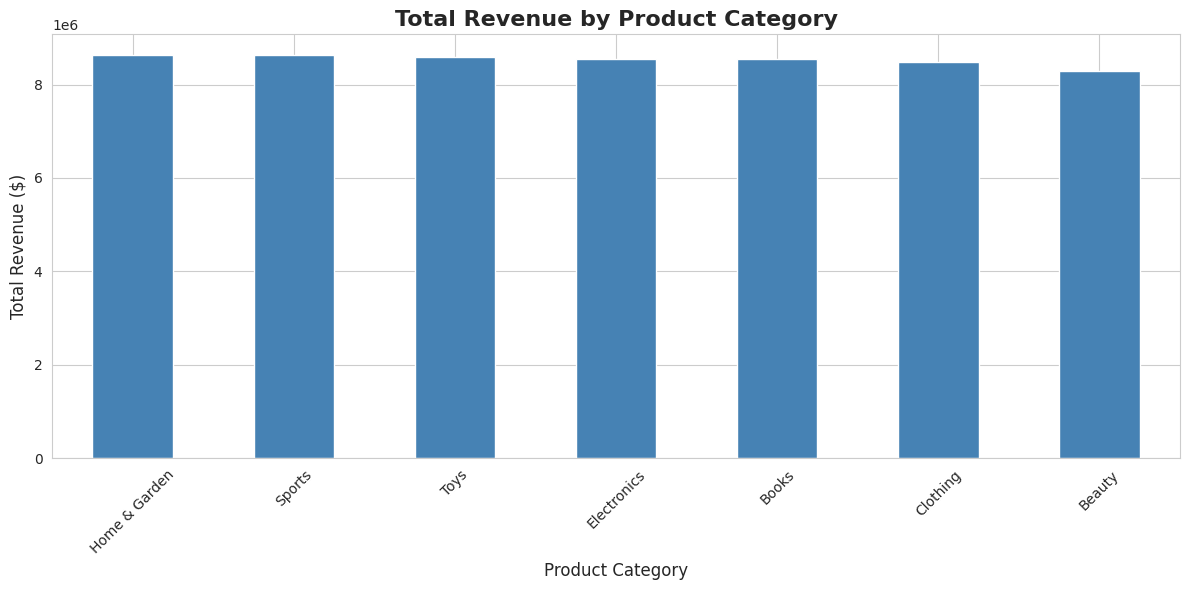

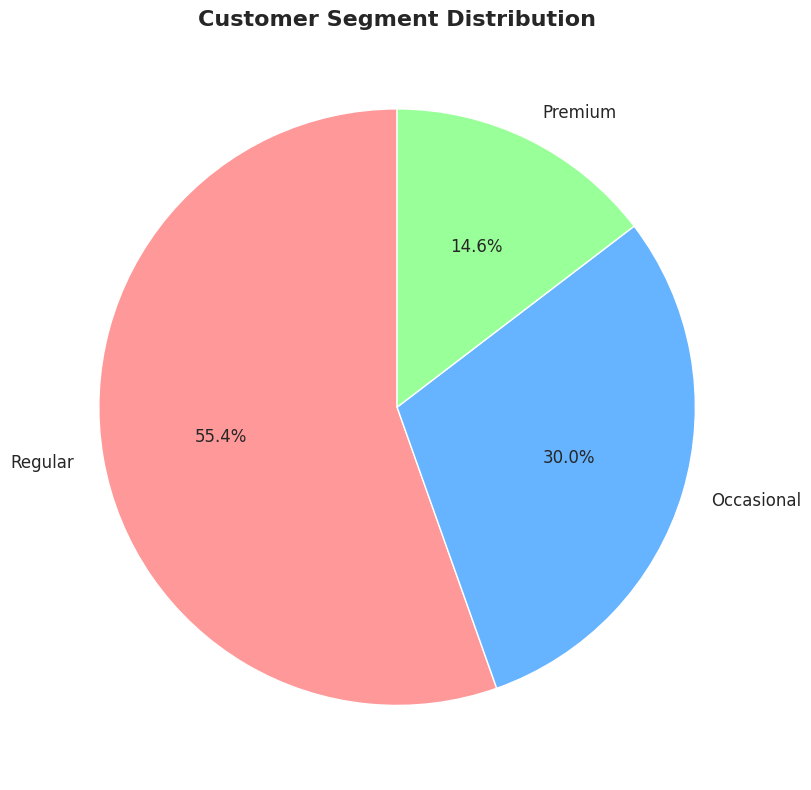

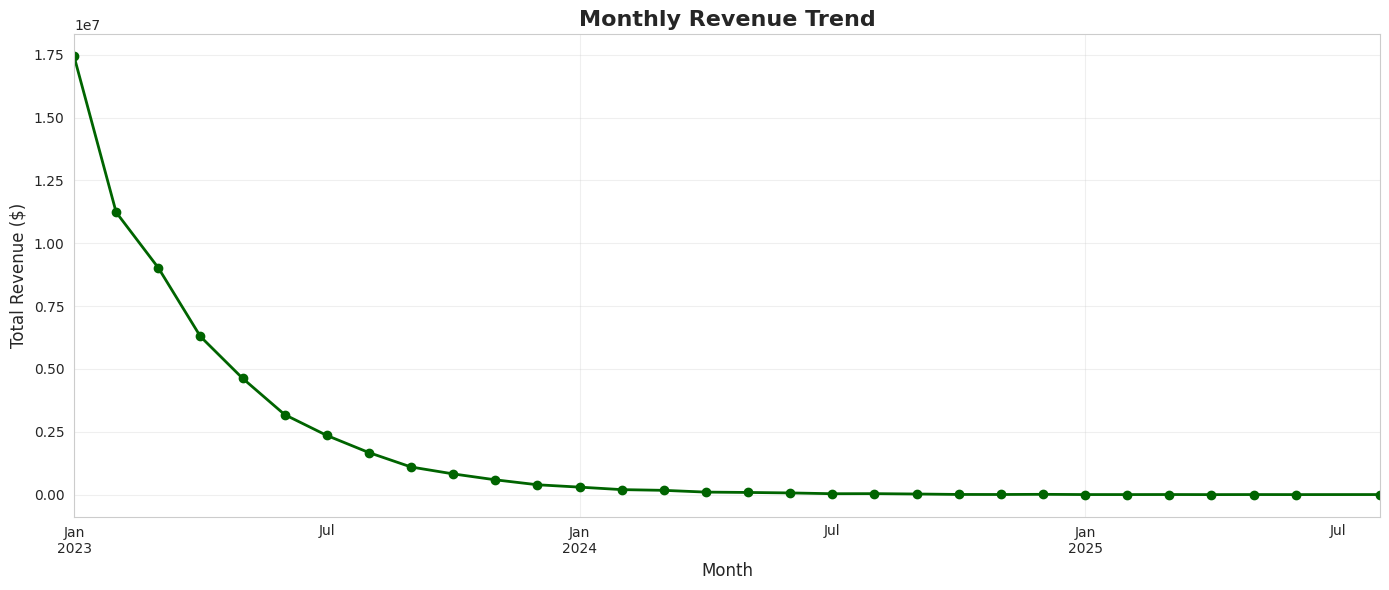

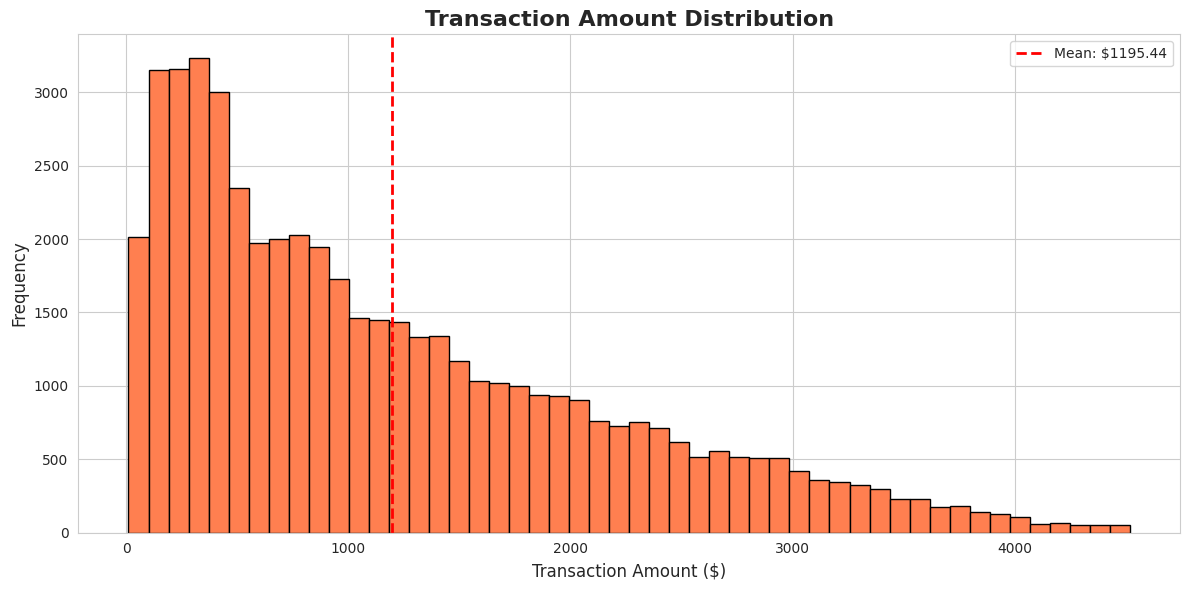

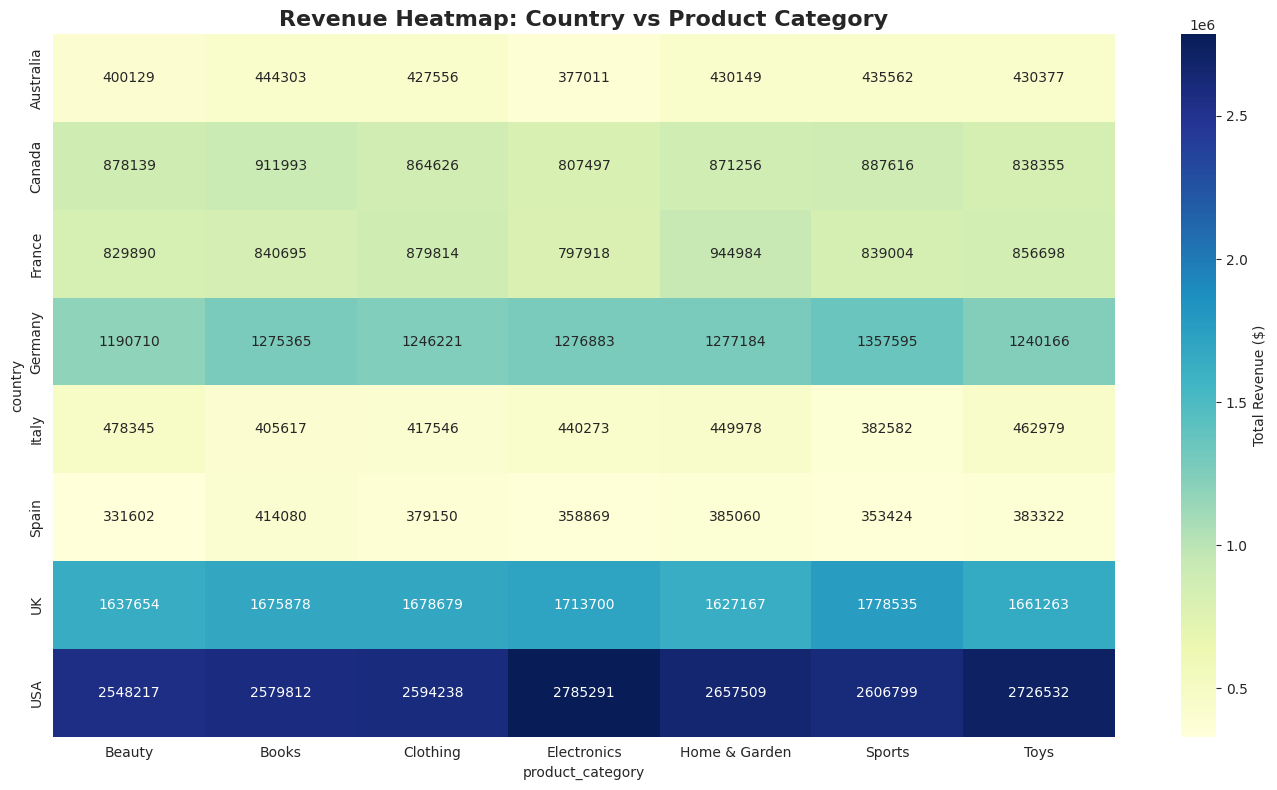

In [19]:
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# 1. Revenue by Category (Bar Chart)
fig1, ax1 = plt.subplots(figsize=(12, 6))
revenue_by_category.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Total Revenue by Product Category', fontsize=16, fontweight='bold')
ax1.set_xlabel('Product Category', fontsize=12)
ax1.set_ylabel('Total Revenue ($)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('revenue_by_category.png', dpi=300, bbox_inches='tight')
print("✅ Saved: revenue_by_category.png")

# 2. Customer Segmentation Distribution (Pie Chart)
fig2, ax2 = plt.subplots(figsize=(10, 8))
segment_counts = customers_clean['customer_segment'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99']
ax2.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 12})
ax2.set_title('Customer Segment Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('customer_segments.png', dpi=300, bbox_inches='tight')
print("✅ Saved: customer_segments.png")

# 3. Monthly Revenue Trend (Line Chart)
fig3, ax3 = plt.subplots(figsize=(14, 6))
monthly_trend = merged_df.groupby(merged_df['transaction_date'].dt.to_period('M'))['total_amount'].sum()
monthly_trend.plot(ax=ax3, marker='o', linewidth=2, color='darkgreen')
ax3.set_title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
ax3.set_xlabel('Month', fontsize=12)
ax3.set_ylabel('Total Revenue ($)', fontsize=12)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=300, bbox_inches='tight')
print("✅ Saved: monthly_revenue_trend.png")

# 4. Transaction Size Distribution (Histogram)
fig4, ax4 = plt.subplots(figsize=(12, 6))
merged_df['total_amount'].hist(bins=50, ax=ax4, color='coral', edgecolor='black')
ax4.set_title('Transaction Amount Distribution', fontsize=16, fontweight='bold')
ax4.set_xlabel('Transaction Amount ($)', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.axvline(avg_order_value, color='red', linestyle='--', linewidth=2, label=f'Mean: ${avg_order_value:.2f}')
ax4.legend()
plt.tight_layout()
plt.savefig('transaction_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: transaction_distribution.png")

# 5. Heatmap - Revenue by Country and Category
fig5, ax5 = plt.subplots(figsize=(14, 8))
heatmap_data = merged_df.pivot_table(
    values='total_amount',
    index='country',
    columns='product_category',
    aggfunc='sum',
    fill_value=0
)
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax5, cbar_kws={'label': 'Total Revenue ($)'})
ax5.set_title('Revenue Heatmap: Country vs Product Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('revenue_heatmap.png', dpi=300, bbox_inches='tight')
print("✅ Saved: revenue_heatmap.png")

print("\n✅ All visualizations created successfully!")



# SECTION 8: RFM ANALYSIS (Customer Segmentation)



RFM ANALYSIS - CUSTOMER SEGMENTATION

📊 RFM Metrics Summary:
           recency   frequency      monetary
count  5000.000000  5000.00000   5000.000000
mean    685.121000    10.00000  11954.358731
std     115.547903     3.14197   4859.824391
min       1.000000     1.00000     40.027794
25%     626.000000     8.00000   8439.495972
50%     706.000000    10.00000  11573.323727
75%     767.000000    12.00000  15006.114757
max     934.000000    29.00000  31287.058052

🎯 Customer Segments:
segment
Loyal Customers        1445
Potential Loyalists    1439
Champions               853
Lost                    526
At Risk                 470
New Customers           267
Name: count, dtype: int64

💎 Champions (Top 10 Customers):
    customer_id  recency  frequency      monetary  RFM_score    segment
90    CUST00091      445         17  25959.110697         15  Champions
146   CUST00147      601         15  20092.106899         15  Champions
339   CUST00340      562         16  17178.347310         15

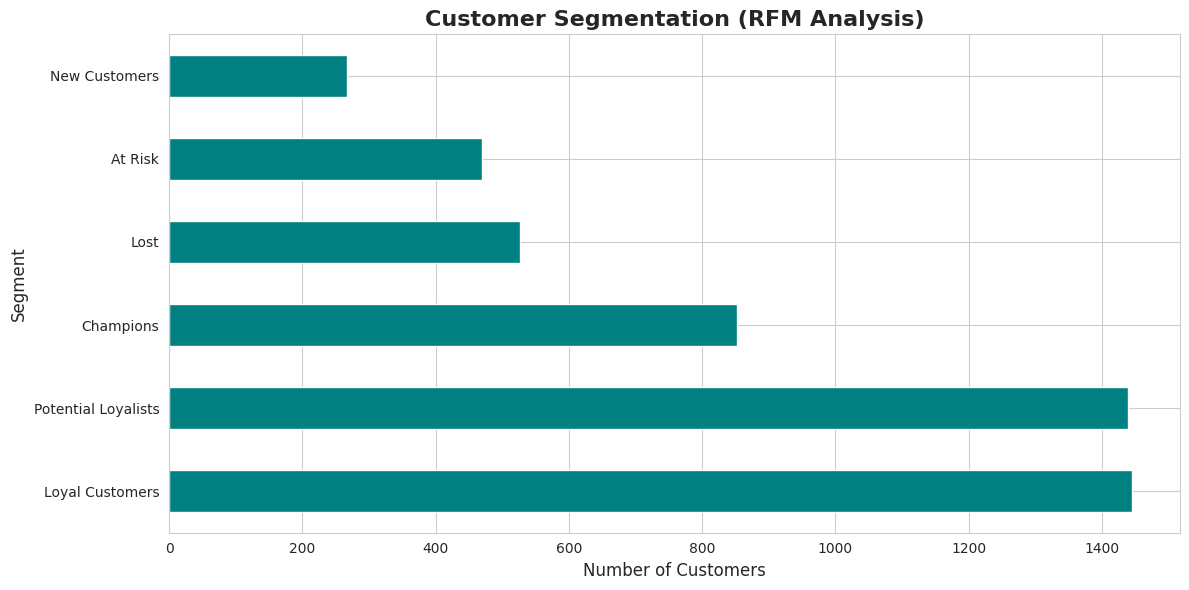

In [20]:
print("\n" + "="*80)
print("RFM ANALYSIS - CUSTOMER SEGMENTATION")
print("="*80)

# Calculate RFM metrics
current_date = merged_df['transaction_date'].max() + timedelta(days=1)

rfm_df = merged_df.groupby('customer_id').agg({
    'transaction_date': lambda x: (current_date - x.max()).days,  # Recency
    'transaction_id': 'count',  # Frequency
    'total_amount': 'sum'  # Monetary
}).reset_index()

rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print("\n📊 RFM Metrics Summary:")
print(rfm_df.describe())

# Create RFM scores (1-5 scale, 5 being best)
rfm_df['R_score'] = pd.qcut(rfm_df['recency'], 5, labels=[5, 4, 3, 2, 1])  # Lower recency = better
rfm_df['F_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'], 5, labels=[1, 2, 3, 4, 5])

# Convert to numeric
rfm_df['R_score'] = rfm_df['R_score'].astype(int)
rfm_df['F_score'] = rfm_df['F_score'].astype(int)
rfm_df['M_score'] = rfm_df['M_score'].astype(int)

# Calculate RFM total score
rfm_df['RFM_score'] = rfm_df['R_score'] + rfm_df['F_score'] + rfm_df['M_score']

# Segment customers based on RFM score
def rfm_segment(row):
    if row['RFM_score'] >= 13:
        return 'Champions'
    elif row['RFM_score'] >= 10:
        return 'Loyal Customers'
    elif row['RFM_score'] >= 7:
        return 'Potential Loyalists'
    elif row['RFM_score'] >= 5 and row['R_score'] >= 3:
        return 'New Customers'
    elif row['RFM_score'] >= 5 and row['R_score'] < 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm_df['segment'] = rfm_df.apply(rfm_segment, axis=1)

print("\n🎯 Customer Segments:")
print(rfm_df['segment'].value_counts())

print("\n💎 Champions (Top 10 Customers):")
print(rfm_df.nlargest(10, 'RFM_score')[['customer_id', 'recency', 'frequency', 'monetary', 'RFM_score', 'segment']])

# Visualize RFM segments
fig6, ax6 = plt.subplots(figsize=(12, 6))
rfm_df['segment'].value_counts().plot(kind='barh', ax=ax6, color='teal')
ax6.set_title('Customer Segmentation (RFM Analysis)', fontsize=16, fontweight='bold')
ax6.set_xlabel('Number of Customers', fontsize=12)
ax6.set_ylabel('Segment', fontsize=12)
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: rfm_segments.png")

# SECTION 9: TIME SERIES FORECASTING



SALES FORECASTING - TIME SERIES ANALYSIS

📅 Time Series Range: 2023-01-01 00:00:00 to 2025-08-01 00:00:00
📊 Total Days: 944

🎓 Training Data: 755 days
🧪 Test Data: 189 days

🔮 Running Exponential Smoothing forecast...

📈 Forecast Accuracy:
   MAE (Mean Absolute Error): $230.02
   MAPE (Mean Absolute Percentage Error): inf%
✅ Saved: sales_forecast.png


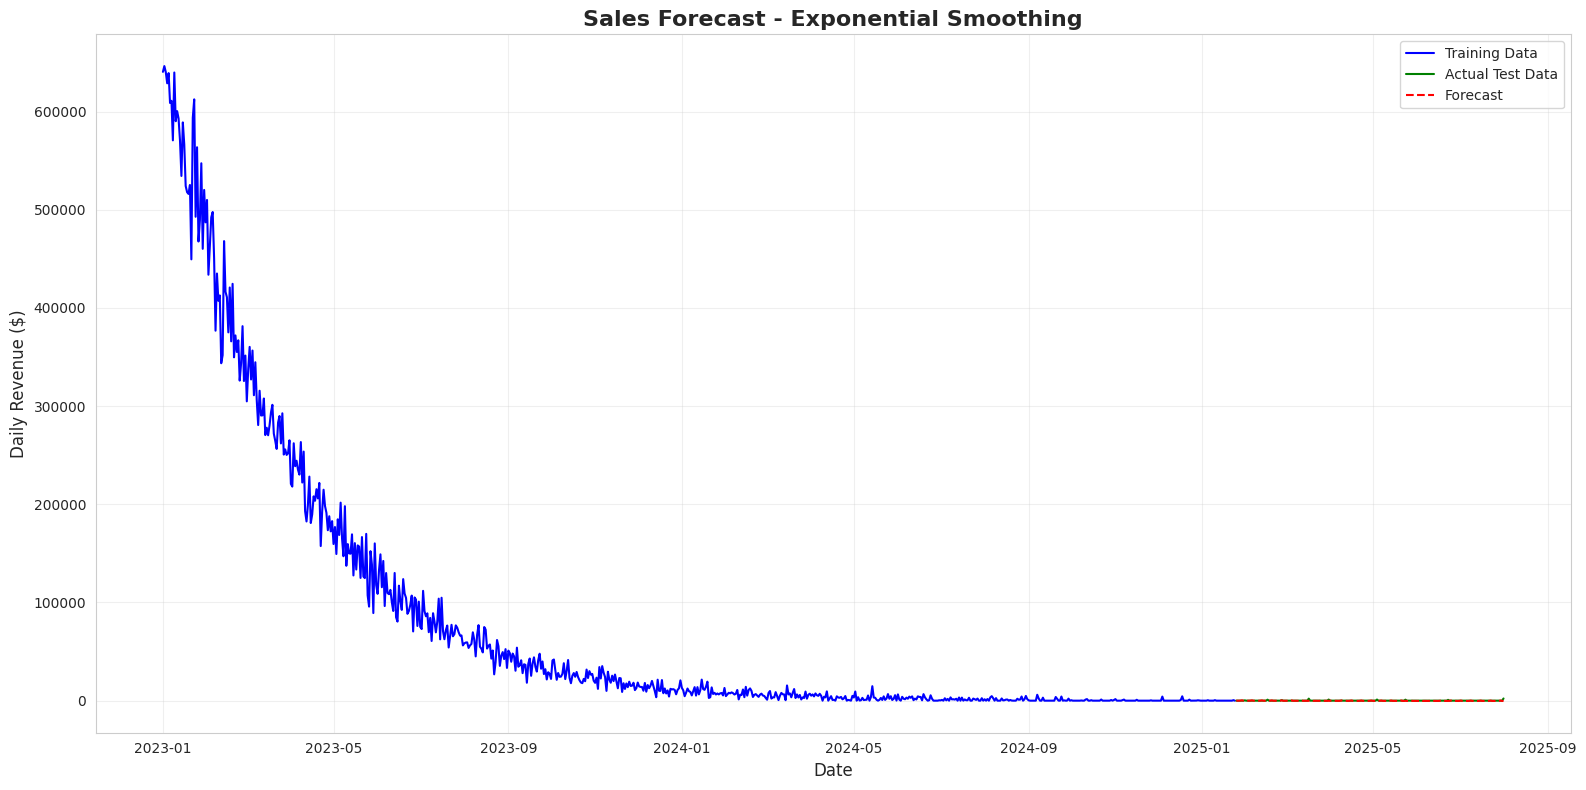

In [21]:
print("\n" + "="*80)
print("SALES FORECASTING - TIME SERIES ANALYSIS")
print("="*80)

# Prepare daily sales data
daily_sales = merged_df.groupby(merged_df['transaction_date'].dt.date)['total_amount'].sum().reset_index()
daily_sales.columns = ['date', 'revenue']
daily_sales['date'] = pd.to_datetime(daily_sales['date'])
daily_sales = daily_sales.set_index('date')
daily_sales = daily_sales.asfreq('D', fill_value=0)  # Fill missing dates

print(f"\n📅 Time Series Range: {daily_sales.index.min()} to {daily_sales.index.max()}")
print(f"📊 Total Days: {len(daily_sales)}")

# Split data for training and testing
train_size = int(len(daily_sales) * 0.8)
train_data = daily_sales[:train_size]
test_data = daily_sales[train_size:]

print(f"\n🎓 Training Data: {len(train_data)} days")
print(f"🧪 Test Data: {len(test_data)} days")

# Exponential Smoothing Forecast
print("\n🔮 Running Exponential Smoothing forecast...")
try:
    model = ExponentialSmoothing(
        train_data['revenue'],
        seasonal_periods=7,  # Weekly seasonality
        trend='add',
        seasonal='add',
        damped_trend=True
    )
    fitted_model = model.fit()

    # Forecast
    forecast = fitted_model.forecast(steps=len(test_data))

    # Calculate error metrics
    mae = np.mean(np.abs(test_data['revenue'] - forecast))
    mape = np.mean(np.abs((test_data['revenue'] - forecast) / test_data['revenue'])) * 100

    print(f"\n📈 Forecast Accuracy:")
    print(f"   MAE (Mean Absolute Error): ${mae:,.2f}")
    print(f"   MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

    # Visualize forecast
    fig7, ax7 = plt.subplots(figsize=(16, 8))
    ax7.plot(train_data.index, train_data['revenue'], label='Training Data', color='blue')
    ax7.plot(test_data.index, test_data['revenue'], label='Actual Test Data', color='green')
    ax7.plot(test_data.index, forecast, label='Forecast', color='red', linestyle='--')
    ax7.set_title('Sales Forecast - Exponential Smoothing', fontsize=16, fontweight='bold')
    ax7.set_xlabel('Date', fontsize=12)
    ax7.set_ylabel('Daily Revenue ($)', fontsize=12)
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('sales_forecast.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: sales_forecast.png")

except Exception as e:
    print(f"⚠️ Forecasting error: {e}")
    print("   Continuing with other analyses...")

# SECTION 10: CLUSTERING ANALYSIS



K-MEANS CLUSTERING - CUSTOMER BEHAVIOR

🎯 Optimal number of clusters: 2

📊 Cluster Distribution:
cluster
0    2714
1    2286
Name: count, dtype: int64

🔍 Cluster Characteristics:
            recency  frequency      monetary
cluster                                     
0        724.447310   7.886883   8710.010101
1        638.431759  12.508749  15806.135713
✅ Saved: customer_clusters.png


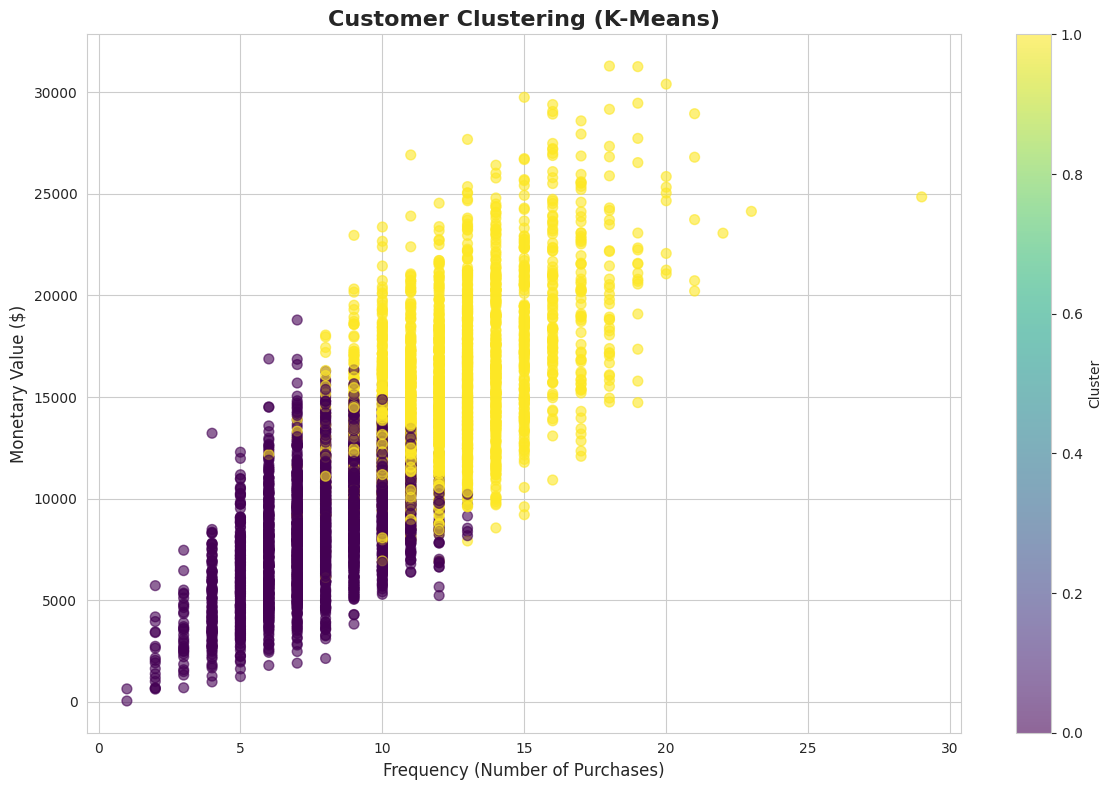

In [22]:
print("\n" + "="*80)
print("K-MEANS CLUSTERING - CUSTOMER BEHAVIOR")
print("="*80)

# Prepare data for clustering
clustering_features = rfm_df[['recency', 'frequency', 'monetary']].copy()

# Standardize features
scaler = StandardScaler()
clustering_scaled = scaler.fit_transform(clustering_features)

# Find optimal number of clusters using silhouette score
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(clustering_scaled)
    score = silhouette_score(clustering_scaled, labels)
    silhouette_scores.append(score)

optimal_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n🎯 Optimal number of clusters: {optimal_k}")

# Perform K-Means with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_df['cluster'] = kmeans_final.fit_predict(clustering_scaled)

print(f"\n📊 Cluster Distribution:")
print(rfm_df['cluster'].value_counts().sort_index())

# Cluster characteristics
print(f"\n🔍 Cluster Characteristics:")
cluster_summary = rfm_df.groupby('cluster')[['recency', 'frequency', 'monetary']].mean()
print(cluster_summary)

# Visualize clusters
fig8, ax8 = plt.subplots(figsize=(12, 8))
scatter = ax8.scatter(
    rfm_df['frequency'],
    rfm_df['monetary'],
    c=rfm_df['cluster'],
    cmap='viridis',
    s=50,
    alpha=0.6
)
ax8.set_xlabel('Frequency (Number of Purchases)', fontsize=12)
ax8.set_ylabel('Monetary Value ($)', fontsize=12)
ax8.set_title('Customer Clustering (K-Means)', fontsize=16, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('customer_clusters.png', dpi=300, bbox_inches='tight')
print("✅ Saved: customer_clusters.png")


# SECTION 11: KEY INSIGHTS & RECOMMENDATIONS

In [24]:
print("\n" + "="*80)
print("KEY INSIGHTS & BUSINESS RECOMMENDATIONS")
print("="*80)

print("\n💡 TOP INSIGHTS:")
print("="*50)

# 1. Revenue Insights
top_category = revenue_by_category.idxmax()
top_category_revenue = revenue_by_category.max()
print(f"\n1️⃣ REVENUE DRIVER:")
print(f"   {top_category} is the highest revenue category (${top_category_revenue:,.2f})")
print(f"   Represents {(top_category_revenue/total_revenue)*100:.1f}% of total revenue")

# 2. Customer Insights
champions_count = (rfm_df['segment'] == 'Champions').sum()
champions_pct = (champions_count / len(rfm_df)) * 100
print(f"\n2️⃣ CUSTOMER SEGMENTATION:")
print(f"   {champions_count} Champions ({champions_pct:.1f}% of customers)")
print(f"   These high-value customers should receive VIP treatment")

# 3. Return Rate Insights
highest_return_category = returns_by_category['return_rate'].idxmax()
highest_return_rate = returns_by_category.loc[highest_return_category, 'return_rate']
print(f"\n3️⃣ QUALITY CONCERN:")
print(f"   {highest_return_category} has highest return rate ({highest_return_rate:.1f}%)")
print(f"   Investigate product quality or description accuracy")

# 4. Geographic Insights
top_country = revenue_by_country.idxmax()
top_country_revenue = revenue_by_country.max()
print(f"\n4️⃣ GEOGRAPHIC OPPORTUNITY:")
print(f"   {top_country} generates most revenue (${top_country_revenue:,.2f})")
print(f"   Consider targeted marketing in this region")

print("\n📈 RECOMMENDATIONS:")
print("="*50)
print("""
1. UPSELLING STRATEGY:
   → Target 'Potential Loyalists' with personalized offers
   → Average order value is ${:.2f}, aim to increase by 15%

2. RETENTION FOCUS:
   → Implement win-back campaign for 'At Risk' customers
   → {} customers ({:.1f}%) need immediate attention

3. INVENTORY OPTIMIZATION:
   → Increase stock for {} category (top seller)
   → Reduce inventory for low-performing categories

4. QUALITY IMPROVEMENT:
   → Address high return rate in {} category
   → Implement better product descriptions and images

5. PERSONALIZATION:
   → Use RFM segments for targeted email campaigns
   → Offer exclusive deals to Champions segment
""".format(
    avg_order_value,
    (rfm_df['segment'] == 'At Risk').sum(),
    ((rfm_df['segment'] == 'At Risk').sum() / len(rfm_df)) * 100,
    top_category,
    highest_return_category
))




KEY INSIGHTS & BUSINESS RECOMMENDATIONS

💡 TOP INSIGHTS:

1️⃣ REVENUE DRIVER:
   Home & Garden is the highest revenue category ($8,643,285.39)
   Represents 14.5% of total revenue

2️⃣ CUSTOMER SEGMENTATION:
   853 Champions (17.1% of customers)
   These high-value customers should receive VIP treatment

3️⃣ QUALITY CONCERN:
   Home & Garden has highest return rate (8.3%)
   Investigate product quality or description accuracy

4️⃣ GEOGRAPHIC OPPORTUNITY:
   USA generates most revenue ($18,498,398.81)
   Consider targeted marketing in this region

📈 RECOMMENDATIONS:

1. UPSELLING STRATEGY:
   → Target 'Potential Loyalists' with personalized offers
   → Average order value is $1195.44, aim to increase by 15%

2. RETENTION FOCUS:
   → Implement win-back campaign for 'At Risk' customers
   → 470 customers (9.4%) need immediate attention

3. INVENTORY OPTIMIZATION:
   → Increase stock for Home & Garden category (top seller)
   → Reduce inventory for low-performing categories

4. QUALITY IM